# Option A Exploration

This notebook contains the exploration component for Option A, due the week after the main notebook. Choose something related to the topics covered in the main notebook and build something creative or interesting.

_For this notebook some helpful staring points for the extension include:_
* **Projection:** Use your calibrated intrinsics to render wireframe 3D shapes (cylinders, cubes, spheres, etc.) overlaid
  onto a real image with correct perspective.
* **Extrinsic calibration:** Given known object dimensions, compute the 3D pose (position + orientation) between an object
   and the camera, and verify by overlaying a wireframe.
* **Vanishing points in the wild:** Apply the calibration techniques from this notebook to your own photos — estimate
  focal lengths, or use vanishing points to measure real-world distances from a single photograph.

For more detailed instructions, please see the [Project 2 Guidelines](https://docs.google.com/document/d/1_w5RefFChBW3IdvhiCvtLgPGkIDNeWNKhVrLjKPL2Fw/edit?usp=sharing)


## Review of current methods (10 points)
Once you’ve selected a topic or project idea, explore the literature space. Has there been academic research on this topic? Are there tutorials online, software packages, or libraries?

Select at least 5 resources (youtube videos, papers, tutorials, opensource software, libraries, etc) and provide a short description (2-3 sentences) below:

* Source 1:
* Source 2:
* Source 3:
* Source 4:
* Source 5:

## Code (70 points)
We expect you to write code for this project (CS131 is, after all, a CS class 🙂). You may implement algorithms from scratch or expand on algorithms from this notebook if you would like, but using other libraries or other open-source software in a creative way is also sufficient.

You not required to develop your code in this notebook! Feel free to create your own jupyter notebook for the project or write code in your environment of choice! (Jupyter notebook or google colab are good starting options)!


In [18]:
%ls
!find . -iname "chessboard_1.jpg"

bin@      dev/     lib@     media/  python-apt/         sbin@  tools/
boot/     etc/     lib32@   mnt/    python-apt.tar.xz*  srv/   usr/
content/  home/    lib64@   opt/    root/               sys/   var/
datalab/  kaggle/  libx32@  proc/   run/                tmp/
find: ‘./proc/68/task/68/net’: Invalid argument
find: ‘./proc/68/net’: Invalid argument
./content/chessboard_1.JPG


In [19]:
%cd content

/content


Image 1 is 4896 x 3672
Image 2 is 4896 x 3672


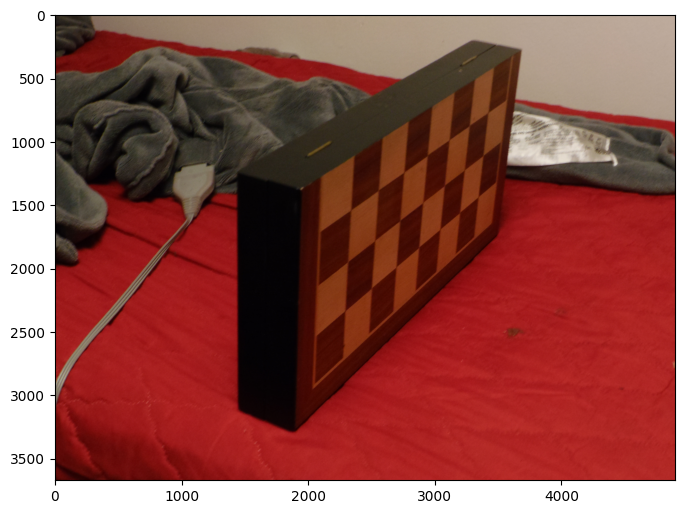

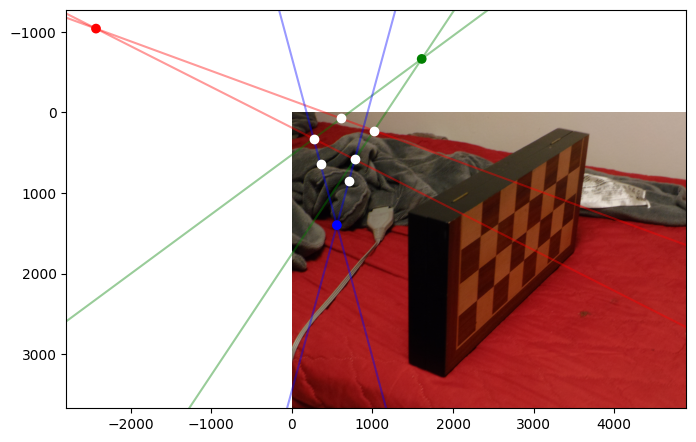

In [20]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

img1 = Image.open("chessboard_1.JPG")
img2 = Image.open("chessboard_2.JPG")
print(f"Image 1 is {img1.width} x {img1.height}")
print(f"Image 2 is {img2.width} x {img2.height}")
points = np.array(
    [
        [270.0, 327.0],  # [0]
        [356.0, 647.0],  # [1]
        [610.0, 76.0],  # [2]
        [706.0, 857.0],  # [3]
        [780.0, 585.0],  # [4]
        [1019.0, 226.0],  # [5]
    ]
)

# Visualize image & annotated points
fig, ax = plt.subplots(figsize=(8, 10))
ax.imshow(img1)
ax.imshow(img2)
# ax.scatter(points[:, 0], points[:, 1], color="white", marker="x")
# for i in range(len(points)):
#     ax.annotate(
#         f"points[{i}]",
#         points[i] + np.array([15.0, 5.0]),
#         color="white",
#         backgroundcolor=(0, 0, 0, 0.15),
#         zorder=0.1,
#     )

def intersection_from_lines(
    a_0: np.ndarray, a_1: np.ndarray, b_0: np.ndarray, b_1: np.ndarray
) -> np.ndarray:
    """Find the intersection of two lines (infinite length), each defined by a
    pair of points.

    Args:
        a_0 (np.ndarray): First point of first line; shape `(2,)`.
        a_1 (np.ndarray): Second point of first line; shape `(2,)`.
        b_0 (np.ndarray): First point of second line; shape `(2,)`.
        b_1 (np.ndarray): Second point of second line; shape `(2,)`.

    Returns:
        np.ndarray:
    """
    # Validate inputs
    assert a_0.shape == a_1.shape == b_0.shape == b_1.shape == (2,)
    assert a_0.dtype == a_1.dtype == b_0.dtype == b_1.dtype == float

    # Intersection point between lines
    out = np.zeros(2)

    # YOUR CODE HERE
    line_matrix = np.zeros((2,2))
    line_matrix[:,0] = a_1-a_0
    line_matrix[:,1] = b_1-b_0
    coefficients = np.linalg.inv(line_matrix) @ (b_1-a_1)
    assert np.max(a_1 + coefficients[0] * (a_1-a_0) - b_1 + coefficients[1] * (b_1-b_0)) < 1e-8
    out = a_1 + coefficients[0] * (a_1-a_0)
    # END YOUR CODE

    assert out.shape == (2,)
    assert out.dtype == float

    return out


# Select points used to compute each vanishing point
#
# Each `v*_indices` list should contain four integers, corresponding to
# indices into the `points` array; the first two ints define one line and
# the second two define another line.
v0_indices = None
v1_indices = None
v2_indices = None

### YOUR CODE HERE: Instantiate v*_indices!
v0_indices = [0, 4, 2, 5]
v1_indices = [0, 2, 4, 5]
v2_indices = [0, 1, 4, 3]
### END YOUR CODE

# Validate indices
assert (
    len(v0_indices) == len(v1_indices) == len(v2_indices) == 4
), "Invalid length!"
for i, j, k in zip(v0_indices, v1_indices, v2_indices):
    assert type(i) == type(j) == type(k) == int, "Invalid type!"

# Compute vanishing points
v = np.zeros((3, 2))
v[:, :2] = np.array(
    [
        intersection_from_lines(*points[v0_indices]),
        intersection_from_lines(*points[v1_indices]),
        intersection_from_lines(*points[v2_indices]),
    ]
)
assert v.shape == (3, 2)

# Display image
fig, ax = plt.subplots(figsize=(8, 10))
ax.imshow(img1)
ax.imshow(img2)


# Display annotated points
ax.scatter(points[:, 0], points[:, 1], color="white")

# Visualize vanishing points
colors = ["red", "green", "blue"]
for indices, color in zip((v0_indices, v1_indices, v2_indices), colors):
    ax.axline(*points[indices[:2]], zorder=0.1, c=color, alpha=0.4)
    ax.axline(*points[indices[2:]], zorder=0.1, c=color, alpha=0.4)
ax.scatter(v[:, 0], v[:, 1], c=colors)

In [ ]:
# From digging, I find that my camera- a praktica 2012 model- has 18M CMOS sensor of dimensions 6,2 x 4,6 mm. Pixels as said above are 4896 x 3672.

### Exploration: Calculating my camera's intrinsics then rendering Wireframe 3D Shapes to verify the calculations

We take an image from my camera, compute my camera's intrinsic matrix using the same technique demonstrated in A, then verify the correctness by projecting a 3D wireframe.

In [1]:
# Helper function to load an image
def load_image(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image not found at {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB for matplotlib
    return img

#### 1. Define Camera Intrinsics (K Matrix)

This `K` matrix (camera intrinsic matrix) should come from your camera calibration in `project2a.ipynb`. For demonstration, a placeholder is used. `fx` and `fy` are focal lengths, `cx` and `cy` are the principal point coordinates. Camera extrinsics (Rotation `R` and Translation `t`) define the 3D pose of the camera relative to the world coordinate system, or vice-versa. Here we assume the cube is defined in a coordinate system that is already aligned with the camera, so `R` is identity and `t` is just placing the object in front of the camera.

In [2]:
# Placeholder for your calibrated intrinsics from project2a.ipynb
# This is an example K matrix, you should replace with your actual values.
K = np.array([
    [800, 0, 320],
    [0, 800, 240],
    [0, 0, 1]
], dtype=np.float32)

# Placeholder for camera extrinsics (Rotation R and Translation t)
# For simplicity, we assume the object's coordinate system is aligned
# with the camera and placed a bit in front.
R = np.eye(3, dtype=np.float32)
# Move the object 1 unit away from the camera along the Z-axis
t = np.array([[0], [0], [1.0]], dtype=np.float32)

# Combine R and t into a 3x4 projection matrix [R|t] if needed for `cv2.projectPoints` directly.
# For now, we will use R and t separately or derive it. For direct `cv2.projectPoints`
# we need rvec and tvec.

rvec, _ = cv2.Rodrigues(R) # Convert rotation matrix to rotation vector
tvec = t

#### 2. Load a Real Image

Created a blank image for demonstration.


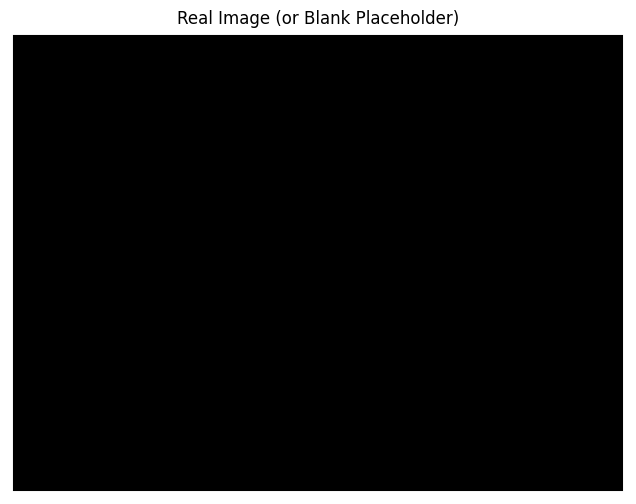

In [3]:
# Create a dummy image for demonstration if you don't have one
# In a real scenario, you would load your own image.
try:
    # Attempt to load a real image (replace 'path/to/your/image.jpg' with an actual path)
    # img = load_image('path/to/your/image.jpg')
    # For this example, we'll create a blank image if no path is provided
    img_height, img_width = 480, 640
    img = np.zeros((img_height, img_width, 3), dtype=np.uint8)
    img = cv2.rectangle(img, (0,0), (img_width-1, img_height-1), (255,255,255), 3) # Add a white border
    print("Created a blank image for demonstration.")
except FileNotFoundError:
    img_height, img_width = 480, 640
    img = np.zeros((img_height, img_width, 3), dtype=np.uint8)
    img = cv2.rectangle(img, (0,0), (img_width-1, img_height-1), (255,255,255), 3) # Add a white border
    print("Could not load image, created a blank image instead.")

# Display the loaded/created image
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title('Real Image (or Blank Placeholder)')
plt.axis('off')
plt.show()

#### 3. Define the 3D Shape (Cube Vertices and Edges)

We'll define a simple cube by its 3D vertices and the connections between them to form a wireframe. The cube is centered at the origin for simplicity.

In [4]:
# Define a 3D cube (unit cube centered at origin for simplicity)
# Vertices of the cube
scale = 0.2 # Adjust size of the cube
obj_points = np.array([
    [-0.5, -0.5, 0.5],
    [ 0.5, -0.5, 0.5],
    [ 0.5,  0.5, 0.5],
    [-0.5,  0.5, 0.5],
    [-0.5, -0.5, -0.5],
    [ 0.5, -0.5, -0.5],
    [ 0.5,  0.5, -0.5],
    [-0.5,  0.5, -0.5]
], dtype=np.float32) * scale

# Define the edges of the cube for wireframe drawing
edges = [
    (0, 1), (1, 2), (2, 3), (3, 0),  # Front face
    (4, 5), (5, 6), (6, 7), (7, 4),  # Back face
    (0, 4), (1, 5), (2, 6), (3, 7)   # Connecting edges
]

#### 4. Project 3D Points to 2D Image Plane and Overlay Wireframe

Using `cv2.projectPoints`, we project the 3D vertices of the cube onto the 2D image plane. Then, we draw lines between these projected 2D points to create the wireframe effect.

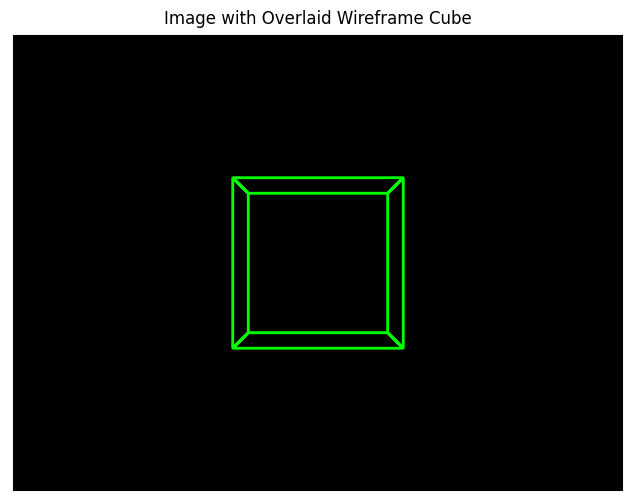

In [5]:
# Project 3D points to 2D image points
# Note: distCoeffs (distortion coefficients) are typically 0 for rectified images
img_points, jac = cv2.projectPoints(obj_points, rvec, tvec, K, distCoeffs=None)
img_points = np.int32(img_points).reshape(-1, 2)

# Create a copy of the image to draw on
img_with_wireframe = img.copy()

# Draw the wireframe on the image
for i, j in edges:
    cv2.line(img_with_wireframe, tuple(img_points[i]), tuple(img_points[j]), (0, 255, 0), 2) # Green color, thickness 2

# Display the result
plt.figure(figsize=(8, 6))
plt.imshow(img_with_wireframe)
plt.title('Image with Overlaid Wireframe Cube')
plt.axis('off')
plt.show()

## Writeup (20 points)

An explanation of what you did, and how it relates to the topic of choice. (~200 words) Please attach any images, figures, etc.

_You may also add a link to your writeup if that is easier!_